# Session 16: Project 3 — Customer Segmentation with AI-Generated Personas

Segment online retail customers into distinct groups using **RFM analysis**
and **K-means clustering**, then use **Google Gemini** to automatically
generate marketing personas for each segment.

| Part | What You Do |
|------|-------------|
| Part 1 | Load & explore the online retail dataset |
| Part 2 | Complete TODOs 1-3 in `segmentation_engine.py`: data cleaning and RFM features |
| Part 3 | Complete TODOs 4-6: feature scaling and K-means clustering |
| Part 4 | Complete TODOs 7-8: visualization and cluster analysis |
| Part 5 | Complete TODOs 9-10: AI personas and the engine class |
| Part 6 | Build the Streamlit dashboard (TODOs 11-15 in `segmentation_app.py`) |
| Part 7 | Reflection & next steps |

In [59]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load API key from .env file (see .env.example)
import os
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    print('python-dotenv not installed. Install with: pip install python-dotenv')
    print('Or set GOOGLE_API_KEY as an environment variable manually.')

API_KEY = os.environ.get('GOOGLE_API_KEY')
if API_KEY:
    print('API key loaded from .env')
else:
    print('No API key found. Persona generation will be skipped.')
    print('To set up: copy .env.example to .env and add your key.')

API key loaded from .env


---
## Part 1: Load & Explore the Dataset

The dataset contains ~8,000 online retail transactions. Each row is
one line item from an invoice — a customer buying a certain quantity
of a product at a given price.

In [60]:
# Load the raw data
df = pd.read_csv('data/online_retail_sample.csv')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Shape: 8000 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV1004,SKU036,Running Shoes,18,2024-03-24 00:00:00,9.15,412.0,United Kingdom
1,INV2466,SKU144,Markers Set,23,2023-12-14 00:00:00,54.72,4.0,United Kingdom
2,INV0654,SKU109,Bookshelf,7,2024-11-22 00:00:00,95.73,403.0,United Kingdom
3,INV1409,SKU068,Blender,18,2024-10-05 00:00:00,12.92,2.0,France
4,INV1482,SKU050,Jeans,8,2024-09-21 00:00:00,77.41,721.0,Sweden


In [61]:
# Data types and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    8000 non-null   object 
 1   StockCode    8000 non-null   object 
 2   Description  8000 non-null   object 
 3   Quantity     8000 non-null   int64  
 4   InvoiceDate  8000 non-null   object 
 5   UnitPrice    8000 non-null   float64
 6   CustomerID   7592 non-null   float64
 7   Country      8000 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 500.1+ KB


In [62]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\n{df["CustomerID"].isnull().sum()} rows have no CustomerID '
      f'({df["CustomerID"].isnull().mean():.1%} of data)')

Missing values per column:
InvoiceNo        0
StockCode        0
Description      0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     408
Country          0
dtype: int64

408 rows have no CustomerID (5.1% of data)


In [63]:
# Quick data quality checks
print(f'Negative Quantity rows (returns): {(df["Quantity"] < 0).sum()}')
print(f'Zero/negative UnitPrice rows:     {(df["UnitPrice"] <= 0).sum()}')
print(f'Unique customers (non-null):       {df["CustomerID"].nunique()}')
print(f'Unique invoices:                   {df["InvoiceNo"].nunique()}')
print(f'Date range:                        {df["InvoiceDate"].min()} to {df["InvoiceDate"].max()}')

Negative Quantity rows (returns): 265
Zero/negative UnitPrice rows:     0
Unique customers (non-null):       800
Unique invoices:                   2354
Date range:                        2023-12-01 00:00:00 to 2024-11-30 00:00:00


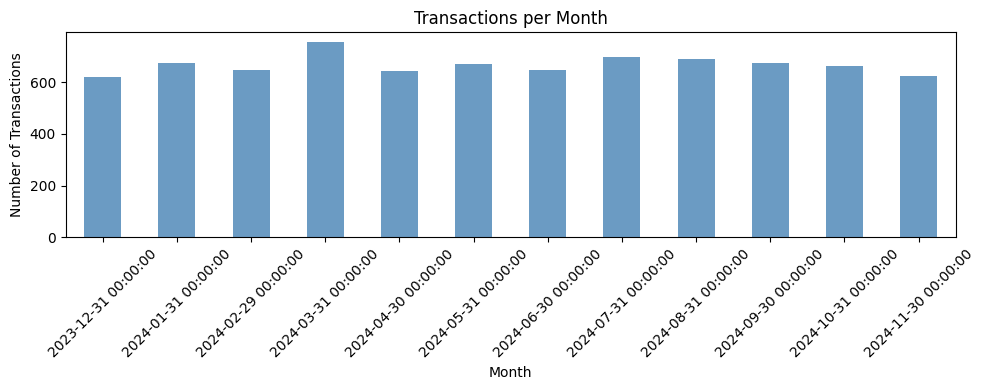

In [64]:
# Transactions over time
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
monthly = df.set_index('InvoiceDate').resample('M').size()

plt.figure(figsize=(10, 4))
monthly.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Transactions per Month')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Part 2: Data Cleaning & RFM Features

Open `segmentation_engine.py` and complete **TODOs 1-3**.

### TODO 1: `load_and_clean(filepath)`
Clean the raw transactions: drop missing CustomerIDs, remove returns
and zero-price items, add a TotalPrice column.

### TODOs 2-3: `build_rfm(df)`
Create one row per customer with three features.

### Why RFM? Real-world context

RFM analysis has been a standard customer segmentation technique in
marketing and CRM since the 1990s. It's used by companies ranging
from e-commerce retailers to subscription services to banks.

The reason it works in practice:

- **Recency** captures engagement — customers who bought recently are
  more likely to respond to campaigns. Direct mail marketers discovered
  this decades ago: response rates drop sharply with time since last purchase.

- **Frequency** captures loyalty — repeat buyers are cheaper to retain
  than new customers are to acquire. The rule of thumb is that acquiring
  a new customer costs 5-7x more than retaining an existing one.

- **Monetary** captures value — not all customers are equally profitable.
  The Pareto principle applies: roughly 20% of customers drive 80% of revenue.

RFM is used in real businesses for segment-specific campaigns
(e.g., win-back emails for high-Recency customers, loyalty rewards for
high-Frequency buyers, VIP programs for high-Monetary spenders),
customer lifetime value estimation, and churn prediction.

Many companies extend RFM with additional features — average order value,
product category diversity, return rate, time between purchases — but the
core three are the starting point that most analytics teams use.

After completing your TODOs, test below.

In [65]:
# Reload the module after editing (run this after saving your changes)
import importlib
import segmentation_engine
importlib.reload(segmentation_engine)

from segmentation_engine import load_and_clean

clean_df = load_and_clean('data/online_retail_sample.csv')
print(f'Cleaned: {len(clean_df)} transactions (removed {len(df) - len(clean_df)} invalid rows)')
clean_df.head()

Cleaned: 7338 transactions (removed 662 invalid rows)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,INV1004,SKU036,Running Shoes,18,2024-03-24,9.15,412.0,United Kingdom,164.70
1,INV2466,SKU144,Markers Set,23,2023-12-14,54.72,4.0,United Kingdom,1258.56
2,INV0654,SKU109,Bookshelf,7,2024-11-22,95.73,403.0,United Kingdom,670.11
3,INV1409,SKU068,Blender,18,2024-10-05,12.92,2.0,France,232.56
4,INV1482,SKU050,Jeans,8,2024-09-21,77.41,721.0,Sweden,619.28


In [66]:
from segmentation_engine import build_rfm

rfm = build_rfm(clean_df)
print(f'RFM table: {len(rfm)} customers')
rfm.head(10)

RFM table: 800 customers


,CustomerID,Recency,Frequency,Monetary
0,1.0,2,116,78222.29
1,2.0,3,100,70235.53
2,3.0,2,121,77968.14
3,4.0,1,108,75684.52
4,5.0,3,112,76698.43
5,6.0,4,110,67699.19
6,7.0,1,124,79644.24
7,8.0,2,117,87320.24
8,9.0,2,119,74909.44
9,10.0,4,112,60600.83


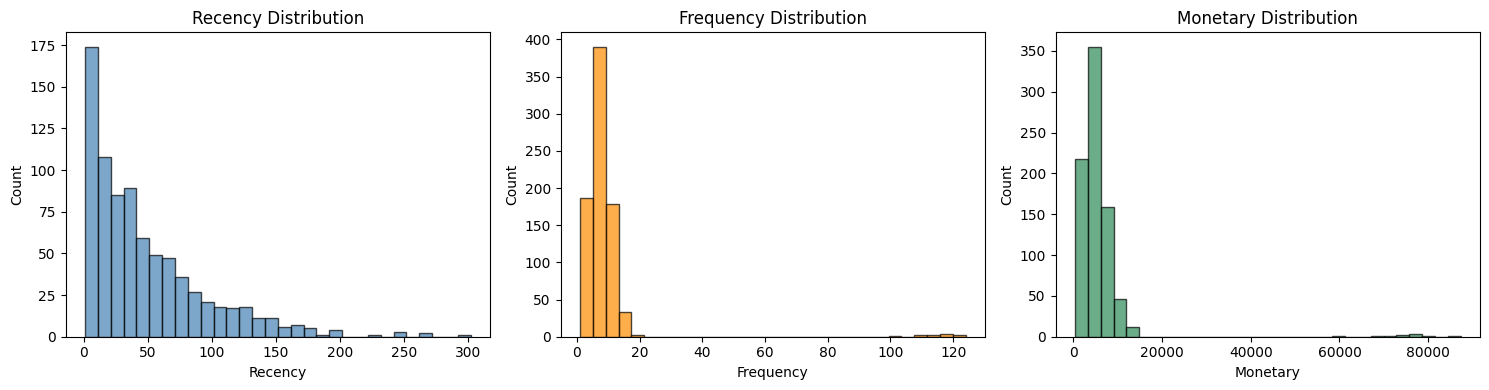

In [67]:
# Visualize RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
                          ['Recency', 'Frequency', 'Monetary'],
                          ['steelblue', 'darkorange', 'seagreen']):
    ax.hist(rfm[col], bins=30, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

### RFM Interpretation

**What do these distributions tell us?**

- **Recency**: Right-skewed — most customers haven't purchased recently.
  A small group bought very recently (low recency = engaged).

- **Frequency**: Heavily right-skewed — most customers made only 1-3
  purchases. A few power users stand out with many orders.

- **Monetary**: Also right-skewed — a small number of high-value customers
  drive a disproportionate share of revenue (the Pareto effect in action).

These skewed distributions are typical in real retail data and are
exactly why segmentation is valuable — treating all customers the same
wastes marketing budget.

---
## Part 3: Feature Scaling & K-Means Clustering

Open `segmentation_engine.py` and complete **TODOs 4-6**.

- **TODO 4**: `scale_features()` — StandardScaler on the RFM columns
- **TODO 5**: `find_optimal_k()` — try K=2 through 8, record inertia + silhouette
- **TODO 6**: `run_kmeans()` — fit KMeans with a chosen K

In [68]:
importlib.reload(segmentation_engine)
from segmentation_engine import scale_features

scaled_data, scaler = scale_features(rfm)
print(f'Scaled shape: {scaled_data.shape}')
print(f'Means (should be ~0): {scaled_data.mean(axis=0).round(4)}')
print(f'Stds  (should be ~1): {scaled_data.std(axis=0).round(4)}')

Scaled shape: (800, 3)
Means (should be ~0): [ 0.  0. -0.]
Stds  (should be ~1): [1. 1. 1.]


In [69]:
from segmentation_engine import find_optimal_k

k_results = find_optimal_k(scaled_data)
k_results

,K,Inertia,Silhouette
0,2,921.975474,0.900908
1,3,383.167196,0.574538
2,4,254.022490,0.447723
3,5,202.464962,0.382252
4,6,162.600086,0.355709
5,7,136.419142,0.351575
6,8,118.230870,0.345577


### Choosing K

Look for:
- The **elbow** in the inertia curve (where it bends)
- The **highest silhouette score** (closer to 1 = better-defined clusters)

Pick a K that balances both. In real projects, business context matters too —
marketing teams typically want 3-5 actionable segments, not 8.

In [70]:
from segmentation_engine import run_kmeans

# Pick your K based on the results above
n_clusters = 4  # Change this based on your analysis

kmeans_model = run_kmeans(scaled_data, n_clusters)
rfm['Cluster'] = kmeans_model.labels_

print(f'Customers per cluster:')
print(rfm['Cluster'].value_counts().sort_index())

Customers per cluster:
Cluster
0     88
1    232
2     10
3    470
Name: count, dtype: int64


---
## Part 4: Visualization & Cluster Analysis

Open `segmentation_engine.py` and complete **TODOs 7-8**.

- **TODO 7**: `plot_elbow_and_silhouette()` — side-by-side K selection plots
- **TODO 8**: `plot_clusters_2d()` — PCA projection colored by cluster

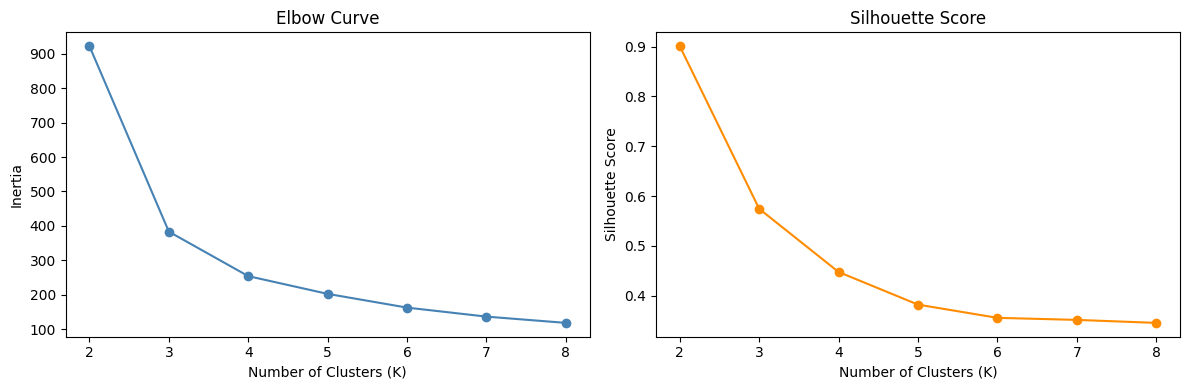

In [71]:
importlib.reload(segmentation_engine)
from segmentation_engine import plot_elbow_and_silhouette

plot_elbow_and_silhouette(k_results)

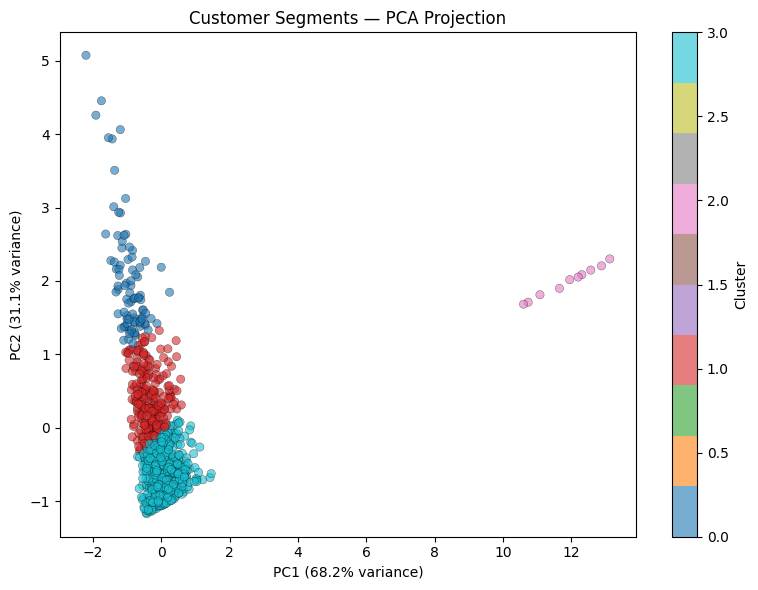

In [72]:
from segmentation_engine import plot_clusters_2d

plot_clusters_2d(scaled_data, kmeans_model.labels_, rfm)

In [73]:
# Cluster profiles: mean RFM values per cluster
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'count'])
print('Cluster profiles:')
cluster_profiles

Cluster profiles:


Recency         Frequency            Monetary      
               mean count        mean count          mean count
Cluster                                                        
0        150.147727    88    5.465909    88   3488.508523    88
1         70.806034   232    7.004310   232   4546.195603   232
2          2.400000    10  113.900000    10  74898.285000    10
3         19.757447   470    8.614894   470   5456.824277   470

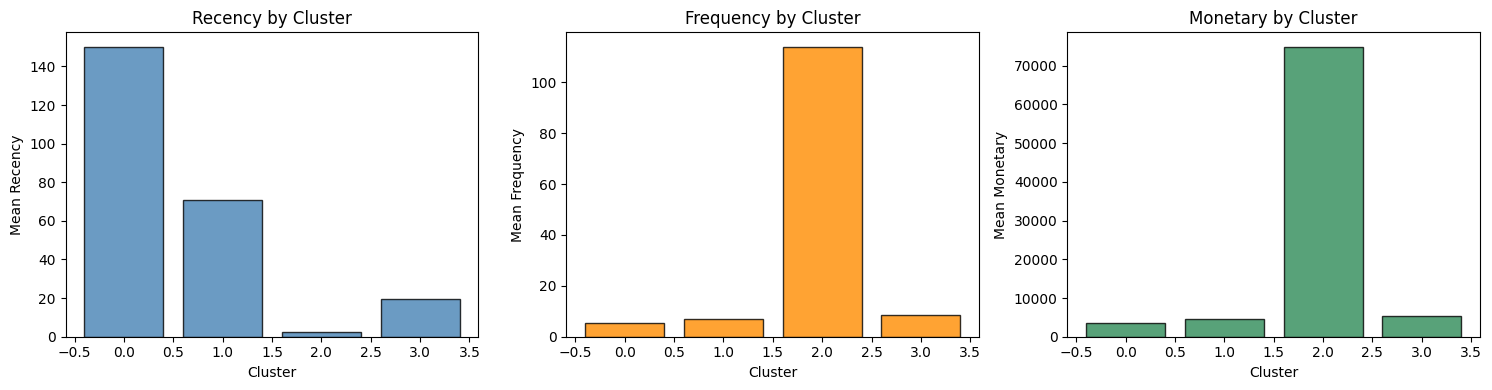

In [74]:
# Cluster profile bar chart
cluster_means = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes,
                          ['Recency', 'Frequency', 'Monetary'],
                          ['steelblue', 'darkorange', 'seagreen']):
    ax.bar(cluster_means.index, cluster_means[col],
           color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(f'Mean {col}')
    ax.set_title(f'{col} by Cluster')

plt.tight_layout()
plt.show()

---
## Part 5: AI-Powered Personas with Gemini

Open `segmentation_engine.py` and complete **TODOs 9-10**.

- **TODO 9**: `generate_persona()` — prompt Gemini with cluster stats
- **TODO 10**: `SegmentationEngine.run_segmentation()` — wire the full pipeline

Your API key should be loaded from your `.env` file (see setup cell above).
If you don't have a key yet, copy `.env.example` to `.env` and add your key.

In [75]:
importlib.reload(segmentation_engine)
from segmentation_engine import generate_persona

# Test persona generation for one cluster
if API_KEY:
    from google import genai
    client = genai.Client(api_key=API_KEY)

    cluster_stats = rfm[rfm['Cluster'] == 0][['Recency', 'Frequency', 'Monetary']].mean()
    persona = generate_persona(cluster_stats, 0, client)
    print('Cluster 0 Persona:')
    print(persona)
else:
    print('Skipping — no API key configured.')
    print('Copy .env.example to .env and add your GOOGLE_API_KEY.')

Cluster 0 Persona:
Here's a detailed marketing persona for Cluster 0:

1.  **Persona Name:** The Valued Patron

2.  **Behavioral Description:** The Valued Patron is a highly engaged and high-spending customer who frequently makes purchases, contributing significantly to revenue. While not always the most recent buyer, their consistent past behavior indicates strong brand loyalty and satisfaction.

3.  **Marketing Recommendations:**
    *   Implement an exclusive loyalty program offering tiered rewards, early access to products, or personalized discounts to acknowledge and further incentivize their high value.
    *   Focus on personalized upselling and cross-selling campaigns, recommending premium products or complementary items based on their past purchase history and high average spend.
    *   Send targeted re-engagement campaigns (e.g., "We miss you!" offers or surveys) if their recency extends, reminding them of their previous positive experiences and offering compelling reasons t

In [76]:
# Test the full SegmentationEngine class
from segmentation_engine import SegmentationEngine

engine = SegmentationEngine('data/online_retail_sample.csv')
engine.run_segmentation(n_clusters=4)

Loading and cleaning data...
Building RFM features...
Scaling features...
Running K-Means with K=4...

Segmentation complete!
         Count  Recency_Mean  Frequency_Mean  Monetary_Mean  Monetary_Total
Cluster                                                                    
0           88         150.1             5.5         3488.5        306988.8
1          232          70.8             7.0         4546.2       1054717.4
2           10           2.4           113.9        74898.3        748982.8
3          470          19.8             8.6         5456.8       2564707.4


In [77]:
# Generate personas for all clusters (requires API key in .env)
if engine.client:
    engine.generate_personas()
else:
    print('Persona generation skipped — no API key.')


Generating personas...

--- Cluster 0 (88 customers) ---
Here is the detailed marketing persona based on your data:

1.  **Persona Name:** The Premium Patron

2.  **Behavioral Description:**
    This segment consists of highly valuable customers who have made substantial monetary contributions over time with a moderate purchase frequency. While they haven't purchased very recently, their high average spend per customer signifies a history of significant engagement and a strong potential for future high-value transactions if re-engaged effectively.

3.  **Marketing Recommendations:**
    *   **Exclusive Re-engagement Campaigns:** Offer personalized, premium incentives like early access to new collections, VIP-only discounts, or complimentary upgrades, directly acknowledging their past high spending.
    *   **Tiered Loyalty Program Invitation:** Proactively invite them to an exclusive top-tier loyalty program with benefits such as dedicated customer support, unique experiential rewards

In [78]:
# View cluster summary
engine.get_cluster_summary()

,Count,Recency_Mean,Frequency_Mean,Monetary_Mean,Monetary_Total
Cluster,,,,,
0,88,150.1,5.5,3488.5,306988.8
1,232,70.8,7.0,4546.2,1054717.4
2,10,2.4,113.9,74898.3,748982.8
3,470,19.8,8.6,5456.8,2564707.4


---
## Part 6: Build the Streamlit Dashboard

Open `segmentation_app.py` and complete **TODOs 11-15**:

- **TODO 11**: Initialize session state for the engine
- **TODO 12**: Handle the Run button (create engine, run segmentation)
- **TODO 13**: Data Overview tab (metrics + RFM histograms)
- **TODO 14**: Cluster Results tab (summary table + PCA plot + profiles)
- **TODO 15**: Persona Generation tab (Gemini integration)

The app reads your API key from `.env` automatically — no need to paste it in the UI.

Run with:
```bash
streamlit run segmentation_app.py
```

Or test the reference solution:
```bash
streamlit run solution/segmentation_app.py
```

---
## Part 7: Reflection & Next Steps

Answer these questions in the cell below:

1. How many clusters did you choose and why?
2. Which cluster is the most valuable to the business? Why?
3. What marketing action would you recommend for each segment?
4. What additional features (beyond RFM) might improve the segmentation?
5. How would you explain your segmentation results to a non-technical stakeholder?

In [ ]:
# Write your reflections here
#
# 1. Number of clusters:
#
# 2. Most valuable cluster:
#
# 3. Marketing recommendations:
#
# 4. Additional features:
#
# 5. Stakeholder explanation:
#